In [3]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax, vmap
from functools import partial

from squarenet import SquareNet


# =========================
# CONFIG
# =========================

I, J = 1000, 1000
N = I * J
D = 2

sigma2 = (3/I)**2
lr = 0.0003


# =========================
# DATA
# =========================

pts = np.random.rand(N, D)


# =========================
# INITIAL STRUCTURE (SquareNet)
# =========================

sqnet = SquareNet(IJ_=(I, J))
sqnet.fit(pts)

points = sqnet.map(pts).reshape(I, J, D)


# =========================
# GRID SHIFTS
# =========================

wr = 6
shifts = jnp.array([
    (di, dj)
    for di in range(-wr, wr+1)
    for dj in range(-wr, wr+1)
    if (di, dj) != (0, 0)
])


# =========================
# INTERACTION (stable form)
# =========================

def interaction(x, y, sigma2):
    delta = (y - x + 0.5) % 1.0 - 0.5
    dist2 = jnp.sum(delta ** 2, axis=-1, keepdims=True)

    w = jnp.exp(-dist2 / sigma2)
    return (2.0/sigma2)*(delta * w) 

def compute_grad(x, sigma2):

    def one_shift(s):
        di, dj = s
        y = jnp.roll(x, (di, dj), axis=(0, 1))
        return interaction(x, y, sigma2)

    grads = vmap(one_shift)(shifts)

    grad = jnp.mean(grads, axis=0)
    
    return grad


# =========================
# ground_stateATION STEP
# =========================

@partial(jax.jit, static_argnames=("max_iter",))
def ground_state(x, max_iter=10, lr=0.1, sigma2=1e-2):

    def step(_, x):
        g = compute_grad(x, sigma2)
        x = x - lr * g

        return x

    return lax.fori_loop(0, max_iter, step, x)

def box(x):
    x = np.array(x)
    return (x - x.min(axis=(0, 1), keepdims= True))/(x.max(axis=(0, 1), keepdims= True) - x.min(axis=(0, 1), keepdims= True))

# =========================
# INITIAL ground_stateATION
# =========================

points = box(ground_state(points, max_iter=20, lr=lr, sigma2=sigma2))


# =========================
# SCHEDULE
# =========================

lr_list = np.linspace(lr, lr/10, 4)


# =========================
# MAIN LOOP
# =========================

for i, lr in enumerate(lr_list):

    print(f"Step {i} | lr={lr:.3f}")

    # 1) structure update (occasionnel)
    flat = points.reshape(-1, D)

    sqnet = SquareNet(IJ_=(I, J))
    sqnet.fit(flat)

    points = sqnet.map(flat).reshape(I, J, D)

    # 2) physical ground_stateation
    points = box(ground_state(points, max_iter=20, lr=lr, sigma2=sigma2))

succesfully sorted at iteration 14
Step 0 | lr=0.000
succesfully sorted at iteration 12
Step 1 | lr=0.000
succesfully sorted at iteration 11
Step 2 | lr=0.000
succesfully sorted at iteration 11
Step 3 | lr=0.000
succesfully sorted at iteration 10


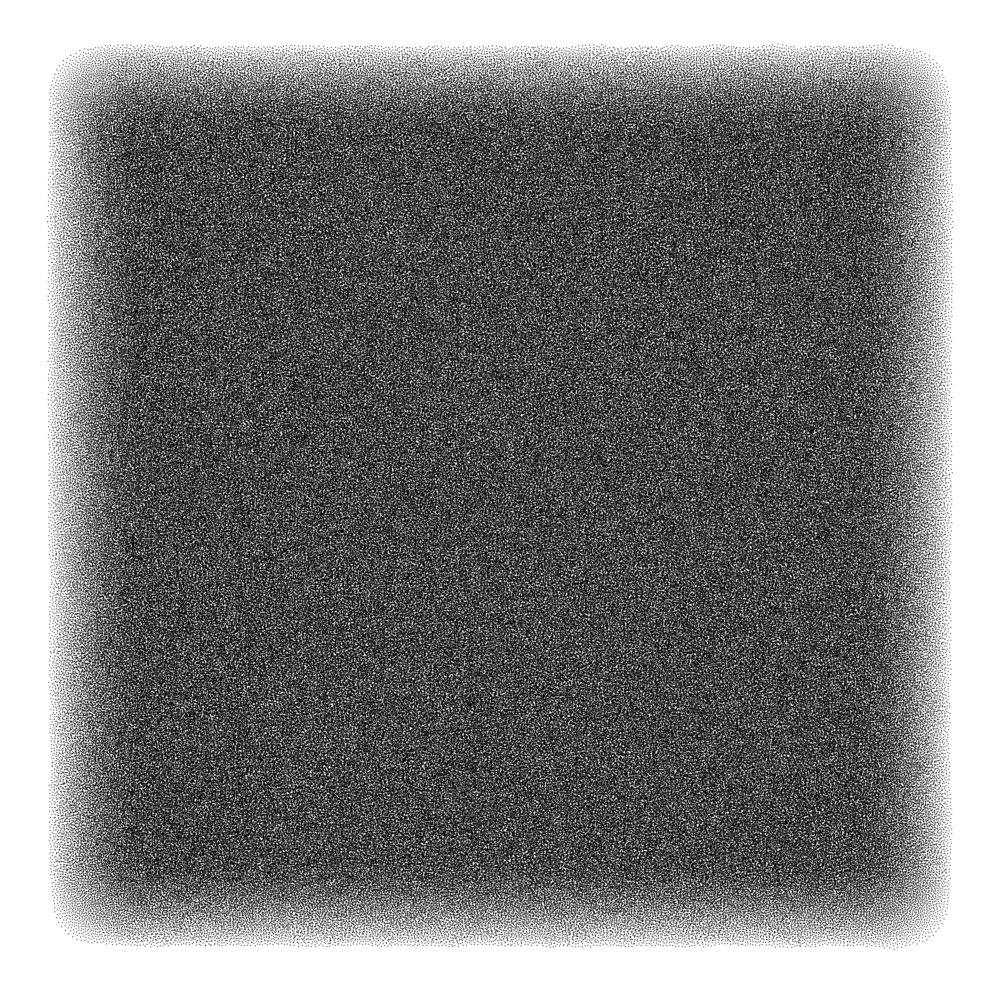

In [20]:
# =========================
# RESULT
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(64, 64))
plt.scatter(points[..., 0].ravel(), points[..., 1].ravel(), s=7, color = "black")
plt.axis("equal")
plt.axis("off")
plt.show()

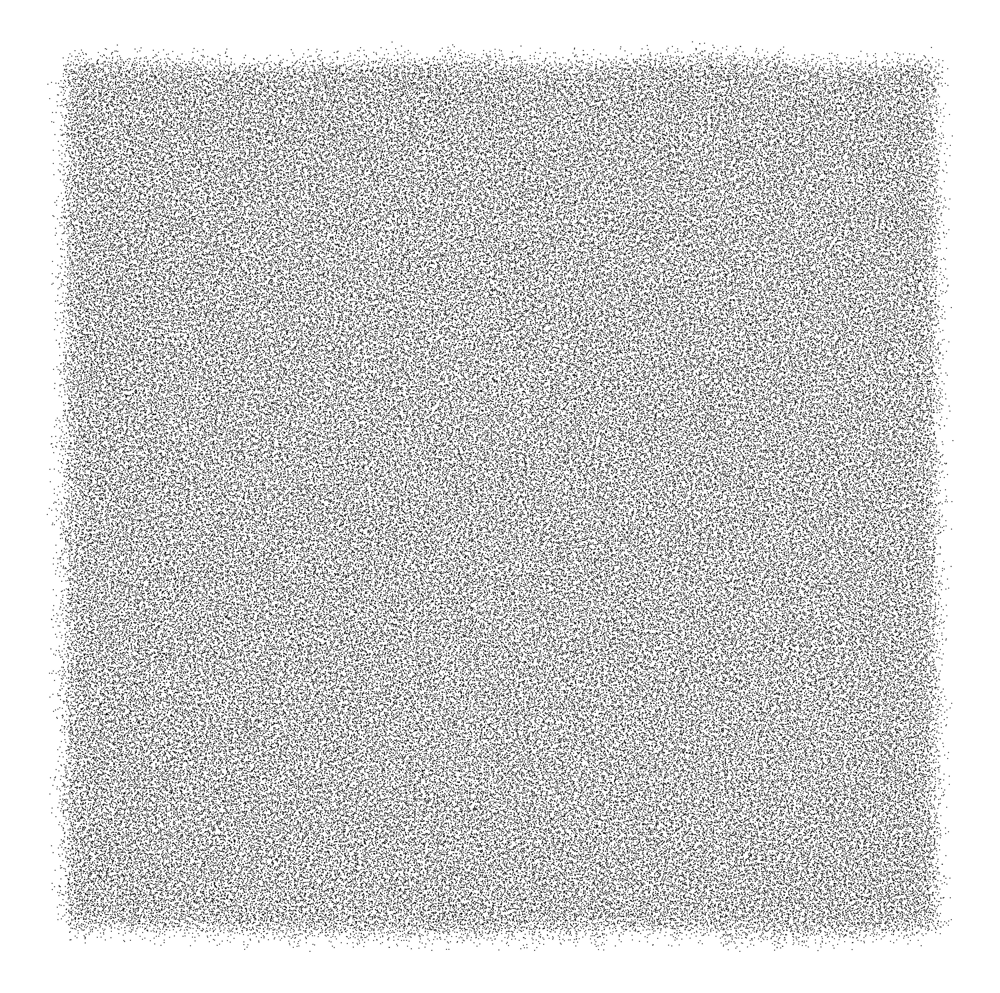

In [21]:
# =========================
# RESULT
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(64, 64))
Im = 250
IM = 750
plt.scatter(points[Im:IM,Im:IM, 0].ravel(), points[Im:IM, Im:IM, 1].ravel(), s=7, color = "black")
plt.axis("equal")
plt.axis("off")
plt.show()